# 회귀분석_최적회귀_정규화_tree회귀

## 보스턴 집값 데이터 회귀분석

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/01%EB%B3%B4%EC%8A%A4%ED%84%B4%EC%A7%91%EA%B0%92%EB%8D%B0%EC%9D%B4%ED%84%B0.csv")

In [3]:
data

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [4]:
# 찰스강경계, 도로접근성은 int 지만 범주형 변수
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   범죄율           506 non-null    float64
 1   25,000평방피트초과  506 non-null    float64
 2   비소매상업지역비율     506 non-null    float64
 3   찰스강경계         506 non-null    int64  
 4   농축 일산화질소      506 non-null    float64
 5   가구당평균방수       506 non-null    float64
 6   1940년이전건축비율   506 non-null    float64
 7   직업센터접근성       506 non-null    float64
 8   도로접근성         506 non-null    int64  
 9   재산세율          506 non-null    float64
 10  학생/교사비율       506 non-null    float64
 11  흑인비율          506 non-null    float64
 12  하위계층비율        506 non-null    float64
 13  주택가격          506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [5]:
data.isna().sum()

범죄율             0
25,000평방피트초과    0
비소매상업지역비율       0
찰스강경계           0
농축 일산화질소        0
가구당평균방수         0
1940년이전건축비율     0
직업센터접근성         0
도로접근성           0
재산세율            0
학생/교사비율         0
흑인비율            0
하위계층비율          0
주택가격            0
dtype: int64

In [6]:
data.describe()

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율,주택가격
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [13]:
data.columns

Index(['범죄율', '25,000평방피트초과', '비소매상업지역비율', '찰스강경계', '농축 일산화질소', '가구당평균방수',
       '1940년이전건축비율', '직업센터접근성', '도로접근성', '재산세율', '학생/교사비율', '흑인비율', '하위계층비율',
       '주택가격'],
      dtype='object')

<Axes: >

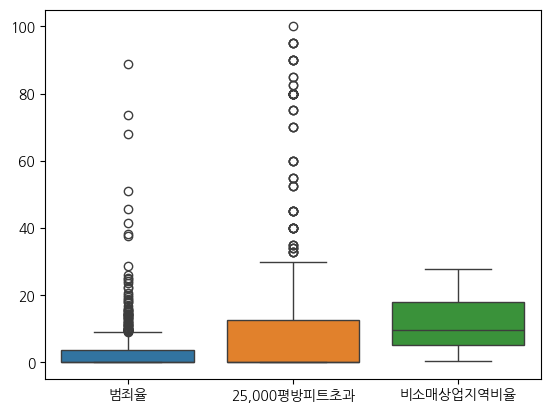

In [19]:
sns.boxplot(data[['범죄율', '25,000평방피트초과', '비소매상업지역비율']])

<Axes: >

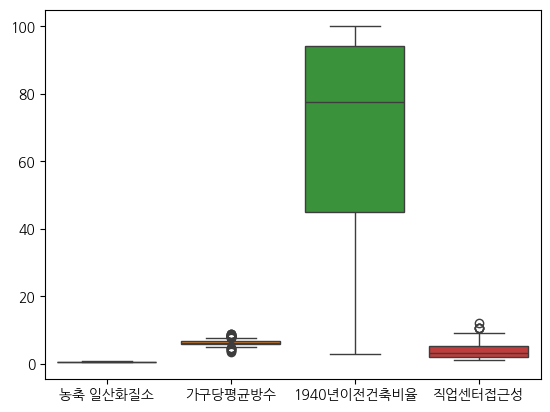

In [16]:
sns.boxplot(data[['농축 일산화질소', '가구당평균방수', '1940년이전건축비율', '직업센터접근성']])

<Axes: >

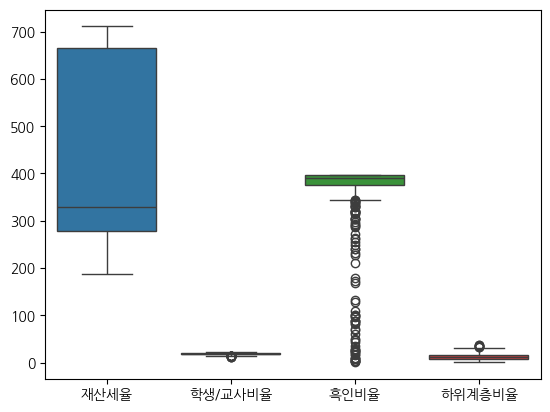

In [20]:
sns.boxplot(data[['재산세율', '학생/교사비율', '흑인비율', '하위계층비율']])

In [8]:
cols = data.columns[:-1]

============================== 범죄율 ==============================


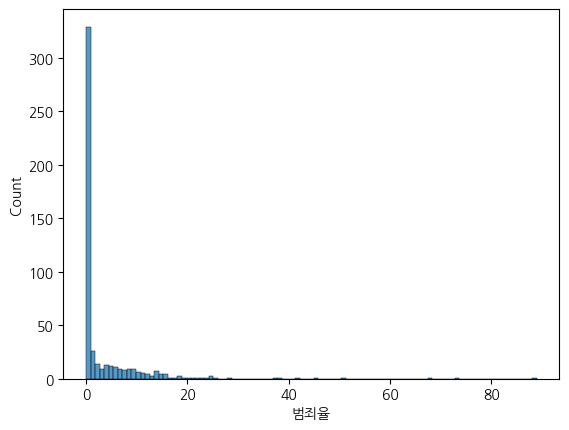

============================== 25,000평방피트초과 ==============================


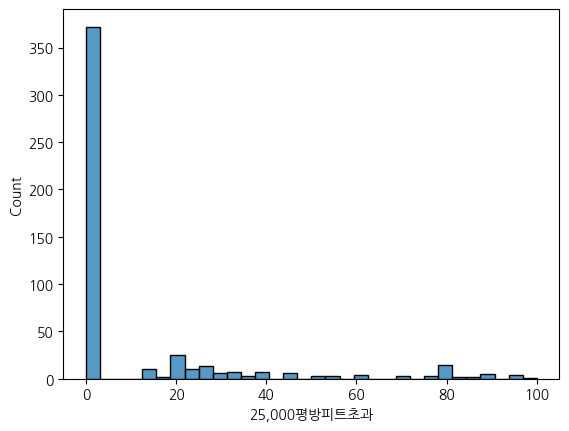

============================== 비소매상업지역비율 ==============================


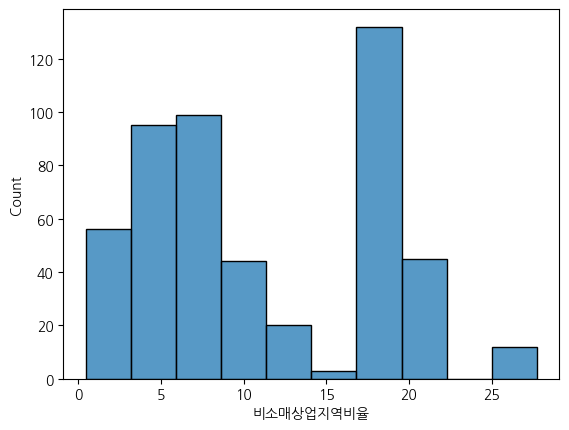

============================== 찰스강경계 ==============================


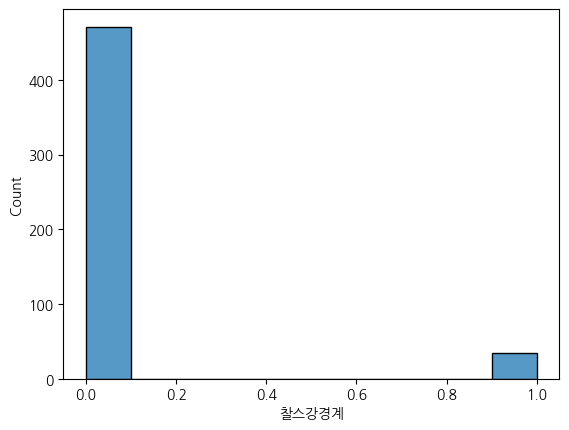

============================== 농축 일산화질소 ==============================


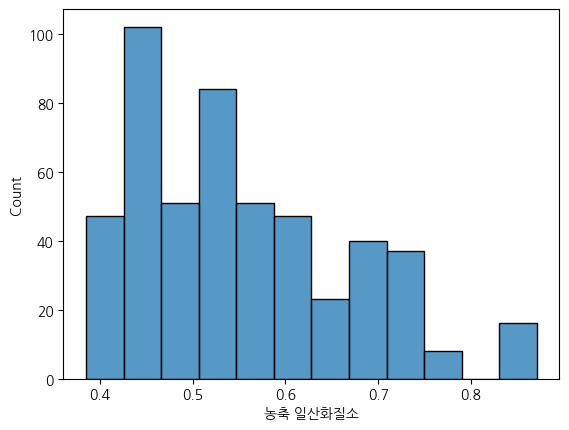

============================== 가구당평균방수 ==============================


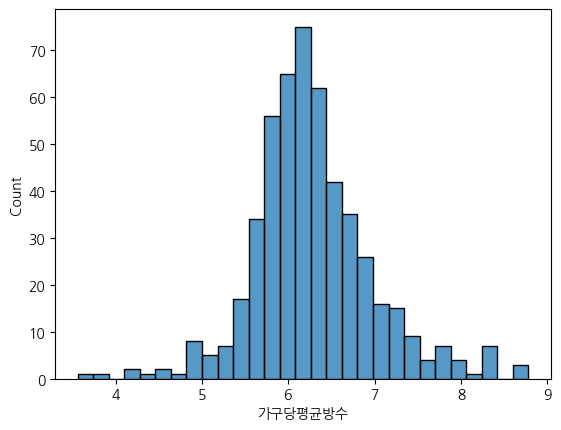

============================== 1940년이전건축비율 ==============================


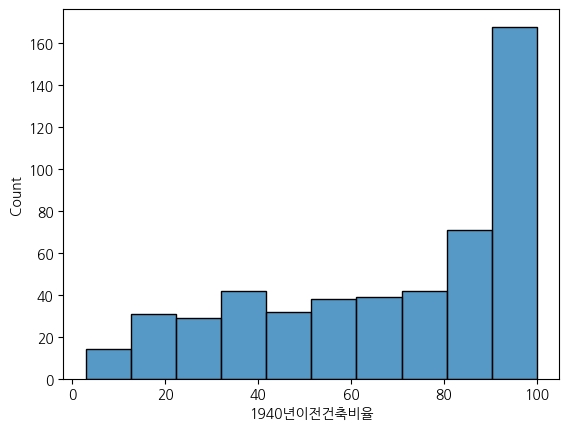

============================== 직업센터접근성 ==============================


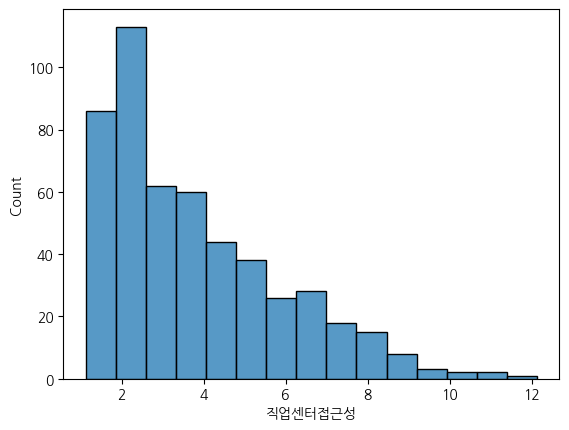

============================== 도로접근성 ==============================


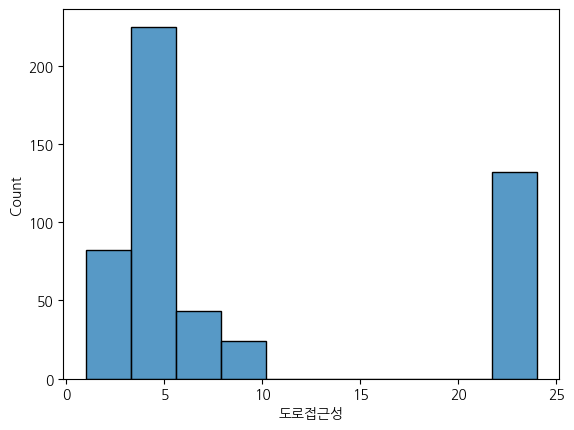

============================== 재산세율 ==============================


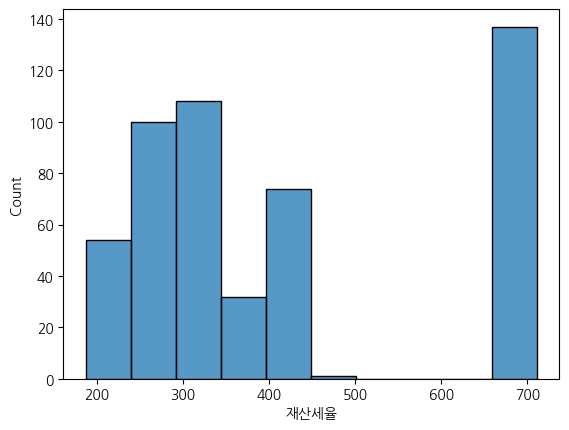

============================== 학생/교사비율 ==============================


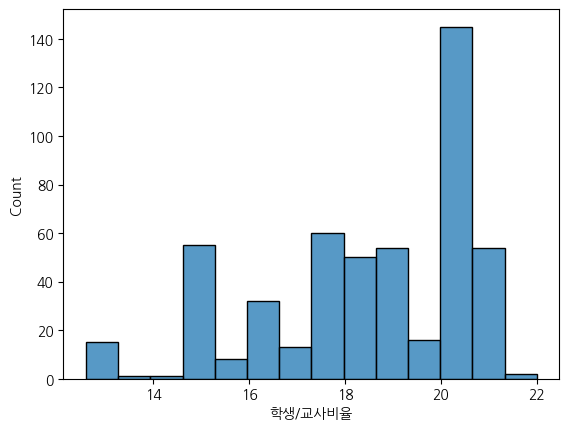

============================== 흑인비율 ==============================


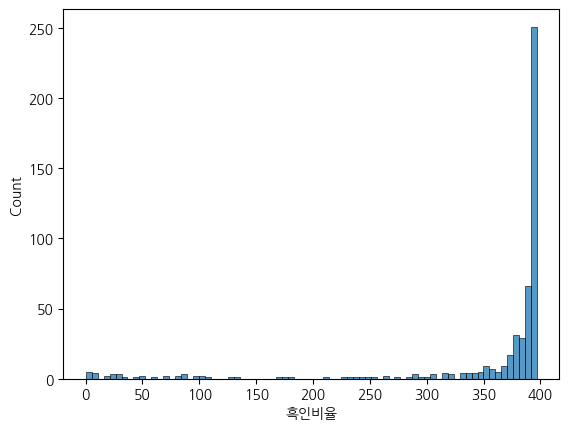

============================== 하위계층비율 ==============================


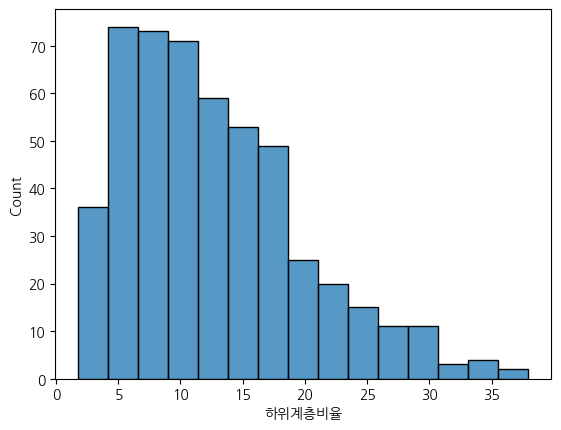

In [9]:
for col in cols:
    print("="*30,col,"="*30)
    sns.histplot(data[col])
    plt.show()

<Axes: >

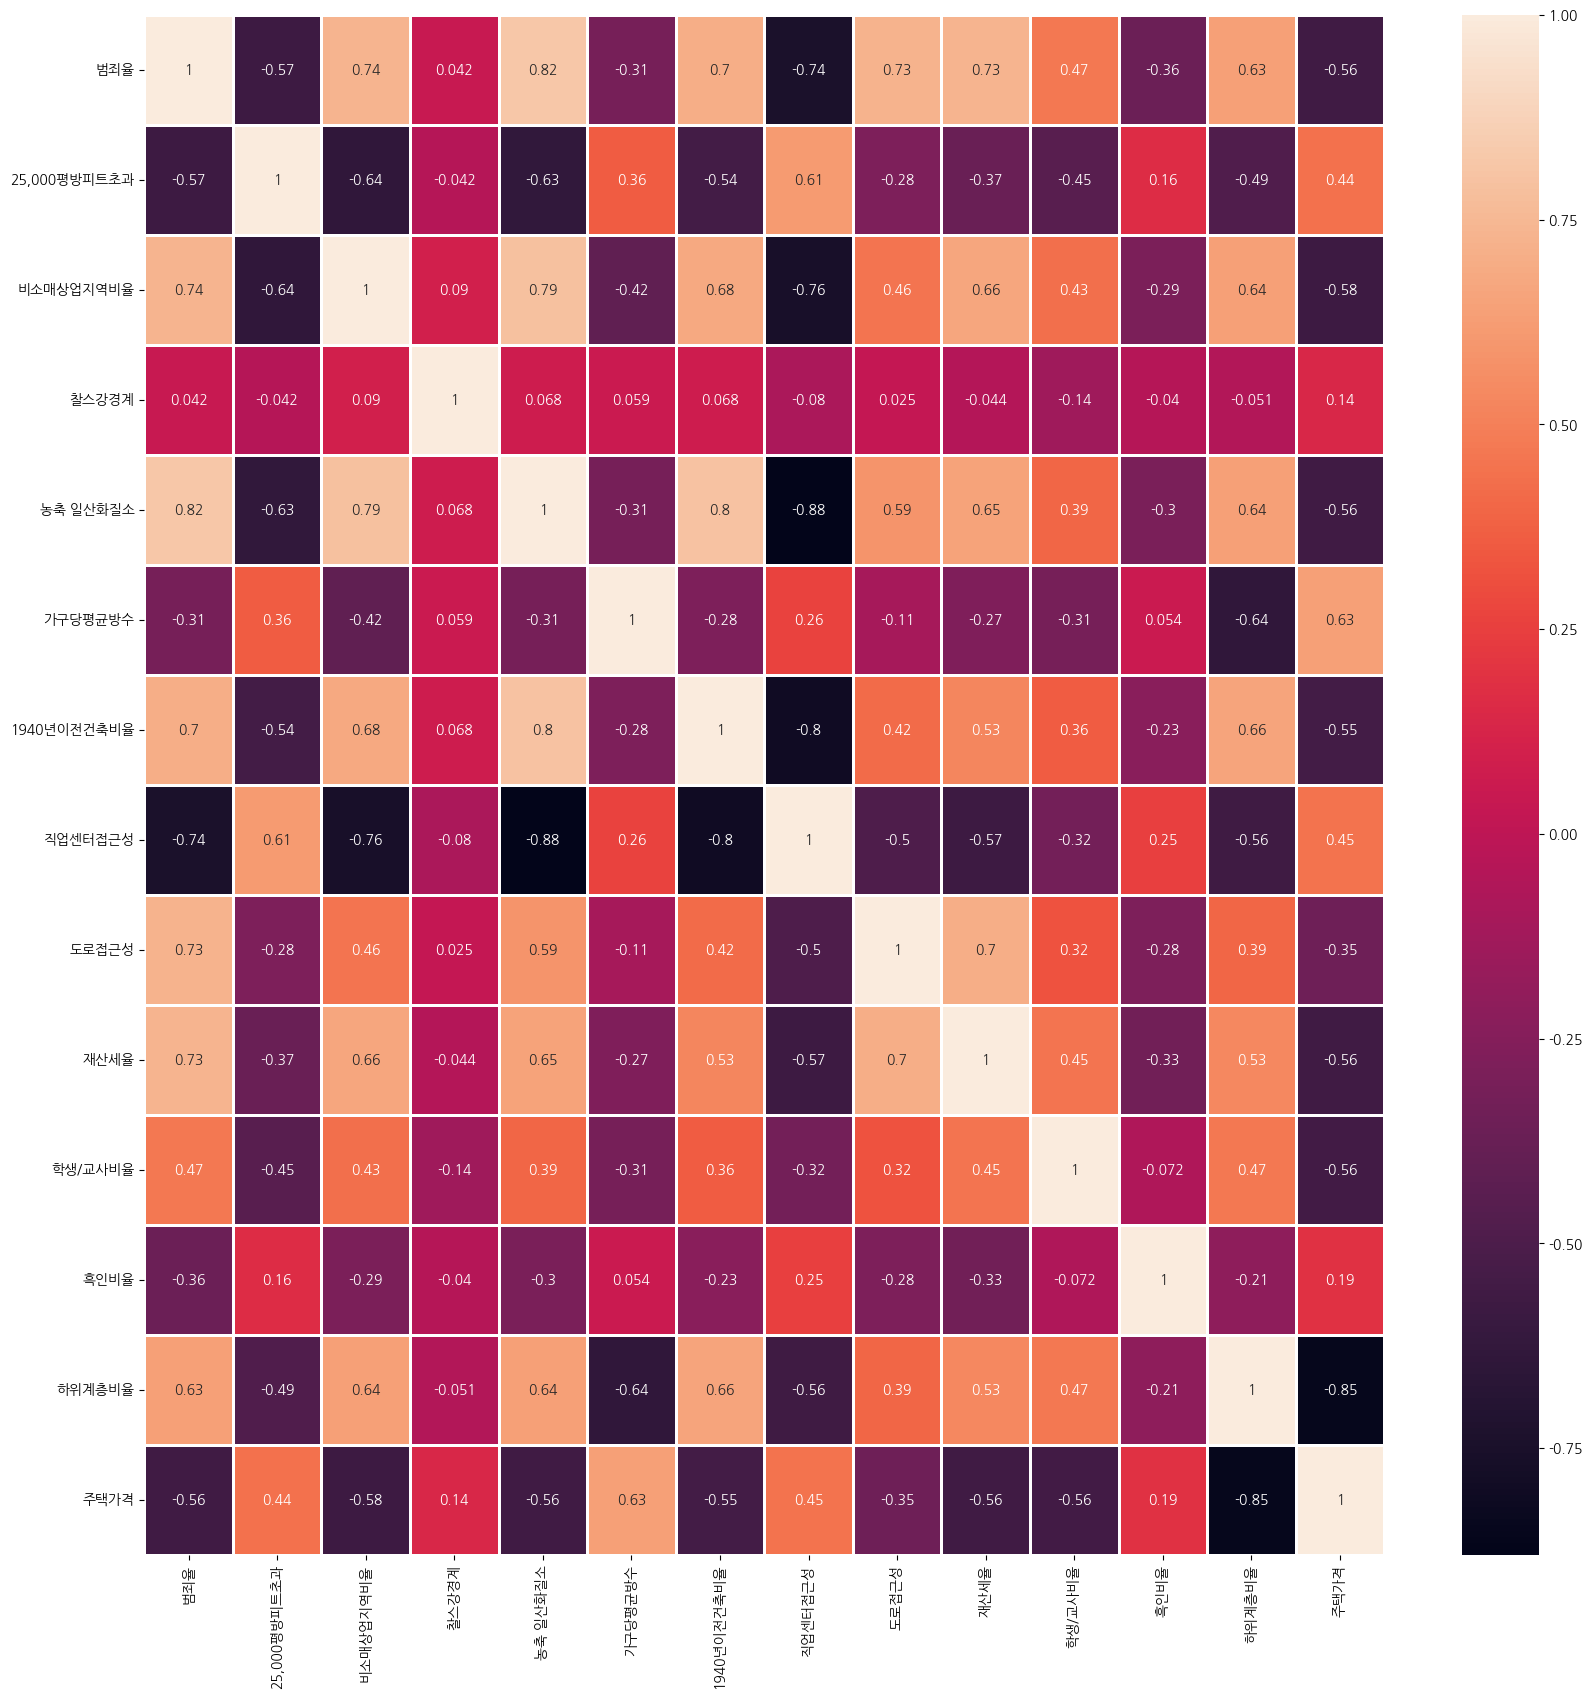

In [22]:
# 수치형 변수가 매우 많으므로 스피어만 상관관계
plt.figure(figsize=(20,20))
sns.heatmap(data.corr(method='spearman'), annot=True, linewidth=1)

In [23]:
X = data.drop('주택가격', axis=1)
y = data['주택가격']

In [24]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [27]:
X_train2 = X_train.copy()
X_test2 = X_test.copy()

#### 스케일 맞추기
* 이상치가 좀 있었으므로 RobustScaler로 스케일 조정

In [28]:
from sklearn.preprocessing import RobustScaler

In [32]:
rs = RobustScaler()
rs.fit(X_train)
rs_X_train = rs.transform(X_train)
rs_X_test = rs.transform(X_test)

# 스케일 맞추는 과정에서 인덱스가 날아가므로 직접 지정
rs_X_train = pd.DataFrame(rs_X_train, columns = X_train.columns, index=X_train.index)
rs_X_test = pd.DataFrame(rs_X_test, columns = X_test.columns, index=X_test.index)

In [33]:
rs_X_train

,범죄율,"25,000평방피트초과",비소매상업지역비율,찰스강경계,농축 일산화질소,가구당평균방수,1940년이전건축비율,직업센터접근성,도로접근성,재산세율,학생/교사비율,흑인비율,하위계층비율
5,-0.070845,0.0,-0.579029,0.0,-0.441989,0.255601,-0.393045,0.888157,-0.10,-0.279070,0.028169,0.129964,-0.610414
116,-0.039048,0.0,0.024672,0.0,0.049724,-0.065005,-0.102213,-0.113375,0.05,0.263566,-0.225352,0.087674,0.119092
45,-0.026596,0.0,-0.214341,0.0,-0.497238,-0.688545,-0.917808,0.599068,-0.10,-0.250646,-0.197183,0.273337,-0.076368
16,0.249243,0.0,-0.119507,0.0,0.000000,-0.369202,-1.012645,0.418185,-0.05,-0.059432,0.676056,-0.244972,-0.464085
468,4.788193,0.0,0.648419,0.0,0.232044,-0.380562,-0.133825,-0.059784,0.95,0.868217,0.450704,-1.178958,0.769559
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,-0.026665,0.0,-0.087124,0.0,-0.099448,-0.494162,0.306639,-0.269402,0.00,0.139535,0.647887,0.209902,0.826168
270,0.013331,1.0,-0.210486,0.0,-0.408840,-0.468918,-0.742887,0.397265,-0.10,-0.276486,0.000000,-0.152140,0.221629
348,-0.075484,4.0,-0.592136,0.0,-0.569061,0.514358,-1.004215,1.574001,-0.05,-0.129199,-0.450704,-0.034038,-0.527103
435,3.408139,0.0,0.648419,0.0,1.116022,0.506784,0.363541,-0.295341,0.95,0.868217,0.450704,-14.530686,1.318558


# statsmodels 선형회귀분석

In [34]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [36]:
# 상수항 추가
rs_X_train_const = sm.add_constant(rs_X_train)
rs_X_test_const = sm.add_constant(rs_X_test)

In [37]:
ols = sm.OLS(y_train, rs_X_train_const).fit()
pred = ols.predict(rs_X_test_const)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_absolute_error(y_test, pred)))
print("R2: ", r2_score(y_test, pred))

MAE:  3.162709871457414
MSE:  21.517444231177297
RMSE:  1.7784009310212965
R2:  0.711226005748492


In [39]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                   주택가격   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     75.81
Date:                Thu, 08 May 2025   Prob (F-statistic):           4.96e-92
Time:                        14:33:42   Log-Likelihood:                -1053.8
No. Observations:                 354   AIC:                             2136.
Df Residuals:                     340   BIC:                             2190.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.9494      0.408     58.755   

In [41]:
result = pd.DataFrame(dict(y_test=y_test, pred=pred))
result

,y_test,pred
173,23.6,28.648960
274,32.4,36.495014
491,13.6,15.411193
72,22.8,25.403213
452,16.1,18.855280
...,...,...
441,17.1,17.403672
23,14.5,13.385941
225,50.0,39.983425
433,14.3,16.682863


In [42]:
result['잔차'] = result['y_test'] - result['pred']
result['잔차제곱'] = (result['잔차'] ** 2)
result['MSE'] = result['잔차제곱'].mean()
result['RMSE'] = result['MSE'].apply(np.sqrt)

# 최적회기 구하기 (단계별 변수 선택법)
* 1) 전진선택법
* 2) 후진제거법

In [43]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

In [44]:
model = LinearRegression()

* 전진선택법으로 분석

In [48]:
sfs_fw = SequentialFeatureSelector(
    estimator=model,
    direction='forward',
    scoring='r2',
    cv = 5,
    n_jobs=4
    )
sfs_fw.fit(rs_X_train_const, y_train)
print(sfs_fw.get_support())
selected_cols = rs_X_train_const.columns[sfs_fw.get_support()]
print('전진선택법으로 선택된 컬럼: ', list(selected_cols))

[False  True False False  True  True  True False  True False False  True
 False  True]
전진선택법으로 선택된 컬럼:  ['범죄율', '찰스강경계', '농축 일산화질소', '가구당평균방수', '직업센터접근성', '학생/교사비율', '하위계층비율']


In [49]:
print("원래 컬럼: ", len(rs_X_train_const.columns))
print("selected_cols: ", len(selected_cols))

원래 컬럼:  14
selected_cols:  7


In [50]:
fw_X_train = rs_X_train_const[['const','범죄율','찰스강경계','농축 일산화질소','가구당평균방수','직업센터접근성','학생/교사비율','하위계층비율']]
fw_X_test = rs_X_test_const[['const','범죄율','찰스강경계','농축 일산화질소','가구당평균방수','직업센터접근성','학생/교사비율','하위계층비율']]

In [52]:
ols2 = sm.OLS(y_train, fw_X_train).fit()
pred = ols2.predict(fw_X_test)
print("MAE: ", mean_absolute_error(y_test, pred))
print("MSE: ", mean_squared_error(y_test, pred))
print("RMSE: ", np.sqrt(mean_absolute_error(y_test, pred)))
print("R2: ", r2_score(y_test, pred))

MAE:  3.310296758822148
MSE:  23.361549390774957
RMSE:  1.8194220947383672
R2:  0.6864772666772769
